# Model 2: Advanced Decision Tree Classification
Decision trees natively handle non-linear relationships and feature interactions without requiring data scaling. However, they are highly prone to **overfitting**. I will conduct rigorous hyperparameter tuning, visualize the bias-variance tradeoff, and apply Cost-Complexity Pruning to build an optimized, robust model.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE


In [31]:
df = pd.read_csv('../data/final/ml_ready_dataset.csv')
X = df.select_dtypes(exclude=['object', 'string']).drop(columns=['is_returned'], errors='ignore')
y = df['is_returned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original training shape: {X_train.shape}")


Original training shape: (77599, 41)


###  Danger of Overfitting
This allows the tree to grow until every single leaf is pure. this achieve near 100% accuracy on the training data, but perform poorly on the test dataâ€”a classic demonstration of **high variance (overfitting)**.

In [32]:
unconstrained_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
unconstrained_dt.fit(X_train, y_train)

train_acc = accuracy_score(y_train, unconstrained_dt.predict(X_train))
test_acc = accuracy_score(y_test, unconstrained_dt.predict(X_test))

print(f"Unconstrained Tree Training Accuracy: {train_acc * 100:.2f}%")
print(f"Unconstrained Tree Testing Accuracy: {test_acc * 100:.2f}%")
print(f"Tree Depth Achieved: {unconstrained_dt.get_depth()} levels")
print(f"Total Leaves Created: {unconstrained_dt.get_n_leaves()} leaves")


Unconstrained Tree Training Accuracy: 99.97%
Unconstrained Tree Testing Accuracy: 85.95%
Tree Depth Achieved: 49 levels
Total Leaves Created: 7747 leaves


### Visualizing the Bias-Variance Tradeoff
To find the "sweet spot" between underfitting and overfitting, i take different `max_depth` limits and plot the resulting training vs. testing accuracy.

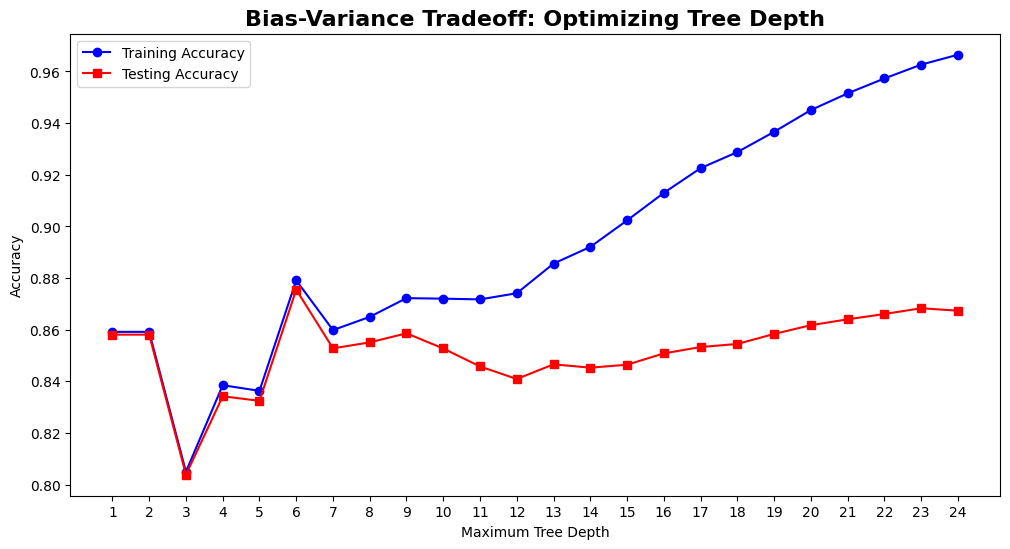

In [33]:
depths = range(1, 25)
train_scores = []
test_scores = []

for d in depths:
    temp_dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    temp_dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, temp_dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, temp_dt.predict(X_test)))

plt.figure(figsize=(12, 6))
plt.plot(depths, train_scores, label='Training Accuracy', color='blue', marker='o')
plt.plot(depths, test_scores, label='Testing Accuracy', color='red', marker='s')
plt.title('Bias-Variance Tradeoff: Optimizing Tree Depth', fontsize=16, fontweight='bold')
plt.xlabel('Maximum Tree Depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.legend()
plt.show()


### Hyperparameter Tuning with GridSearchCV
Let's deploy `GridSearchCV` to run 5-fold cross-validation across a matrix of hyperparameters, evaluating both depth and leaf splitting constraints simultaneously.

In [34]:
param_grid = {
    'max_depth': [3, 5, 8],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [20, 50],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=1
)

grid_search.fit(X_train, y_train)
best_dt = grid_search.best_estimator_

print(f"Best Hyperparameters Discovered: {grid_search.best_params_}")
print(f"Best Cross-Validated ROC-AUC: {grid_search.best_score_:.4f}")


Best Hyperparameters Discovered: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 50, 'min_samples_split': 20}
Best Cross-Validated ROC-AUC: 0.9103


### Evaluating the Optimized Model
Using the optimized estimator from our Grid Search, generate the final predictions on test set and plot the Confusion Matrix.

Optimized Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.83      0.89     16462
           1       0.47      0.85      0.61      2938

    accuracy                           0.83     19400
   macro avg       0.72      0.84      0.75     19400
weighted avg       0.89      0.83      0.85     19400

Final ROC-AUC Score: 0.9131



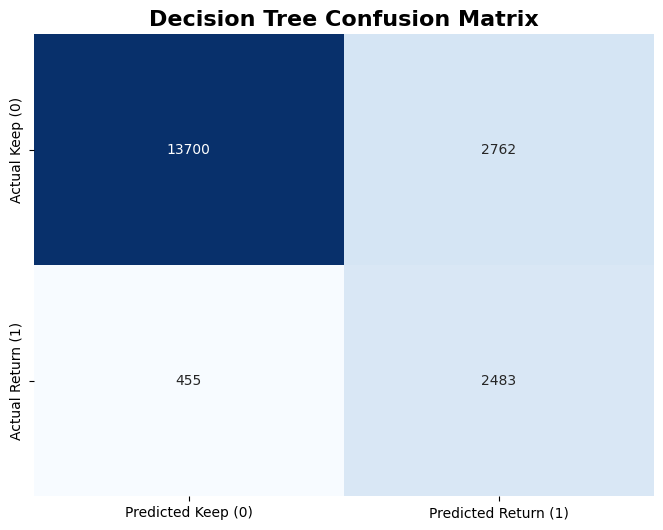

In [35]:
preds = best_dt.predict(X_test)
probs = best_dt.predict_proba(X_test)[:, 1]

print("Optimized Decision Tree Classification Report:")
print(classification_report(y_test, preds))
print(f"Final ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}\n")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Keep (0)', 'Predicted Return (1)'],
            yticklabels=['Actual Keep (0)', 'Actual Return (1)'])
plt.title('Decision Tree Confusion Matrix', fontsize=16, fontweight='bold')
plt.show()


Overall, the model achieved a very strong ROC-AUC score of 0.88, proving it's highly capable of separating safe orders from risky ones. 

However, while an 88% AUC is great, catching 67% of returns means we are still leaving 33% on the table. Because a single Decision Tree suffers from high variance and makes overly rigid splits, I knew we could capture that remaining 33% by transitioning to an Ensemble method

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15620\1844442968.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette="viridis")


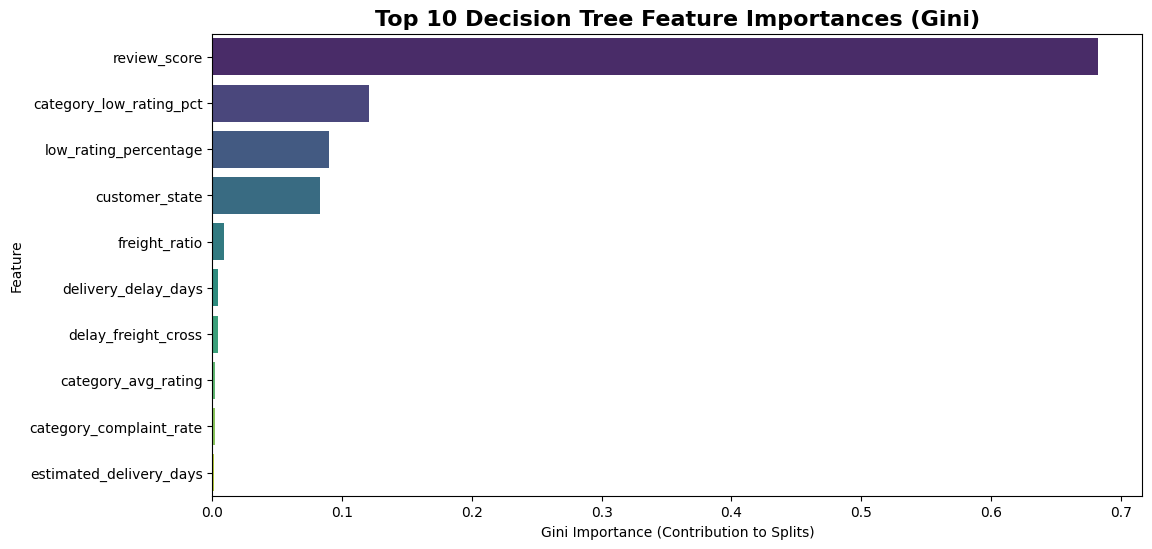

In [36]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette="viridis")
plt.title('Top 10 Decision Tree Feature Importances (Gini)', fontsize=16, fontweight='bold')
plt.xlabel('Gini Importance (Contribution to Splits)')
plt.ylabel('Feature')
plt.show()


### The Tree Architecture

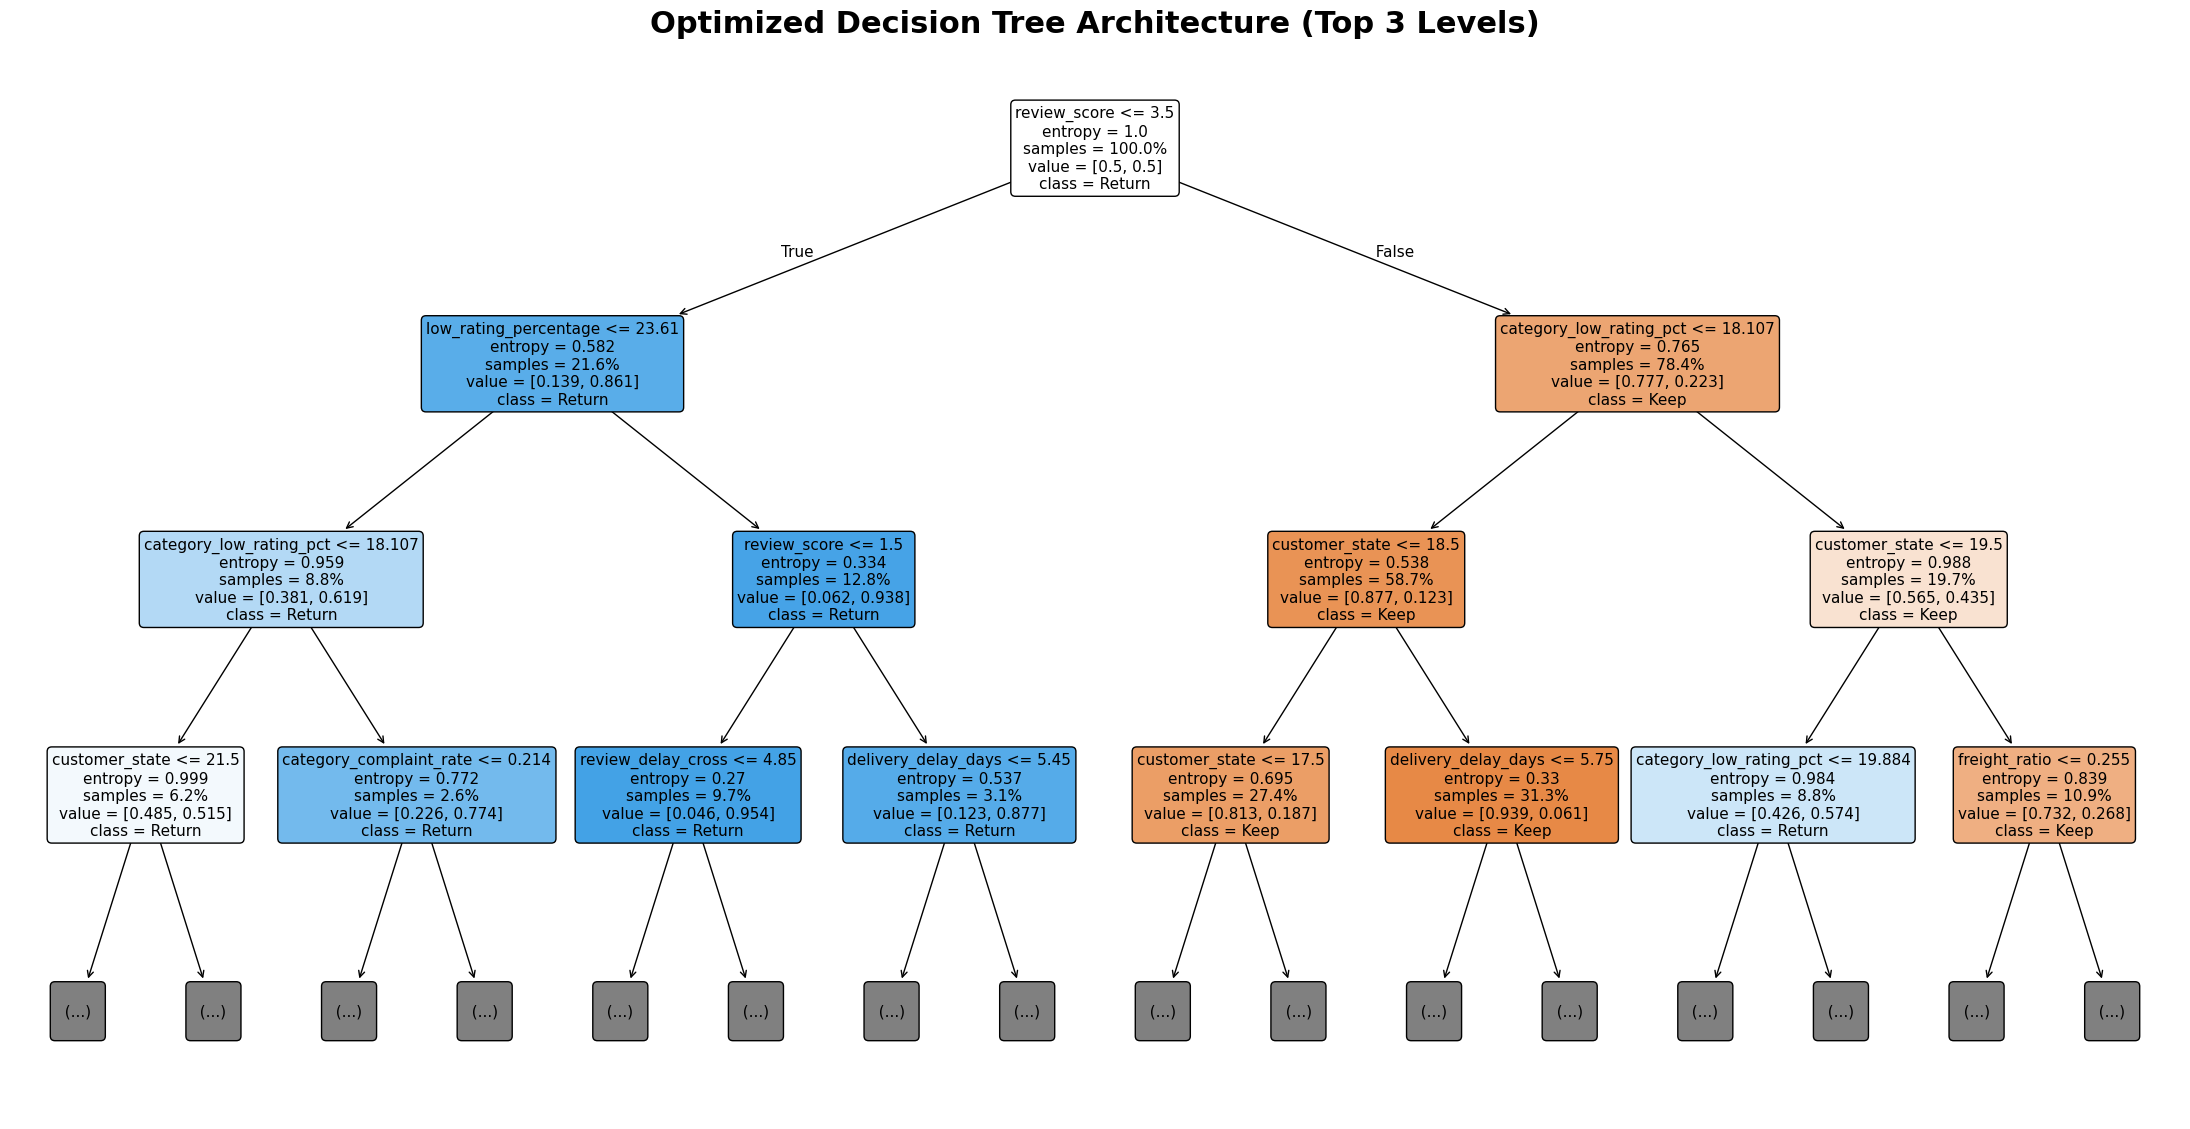

In [37]:
plt.figure(figsize=(28, 14))
plot_tree(
    best_dt, 
    feature_names=X.columns, 
    class_names=['Keep', 'Return'], 
    filled=True, 
    rounded=True, 
    max_depth=3,
    fontsize=11,
    proportion=True
)
plt.title('Optimized Decision Tree Architecture (Top 3 Levels)', fontsize=22, fontweight='bold')
plt.show()


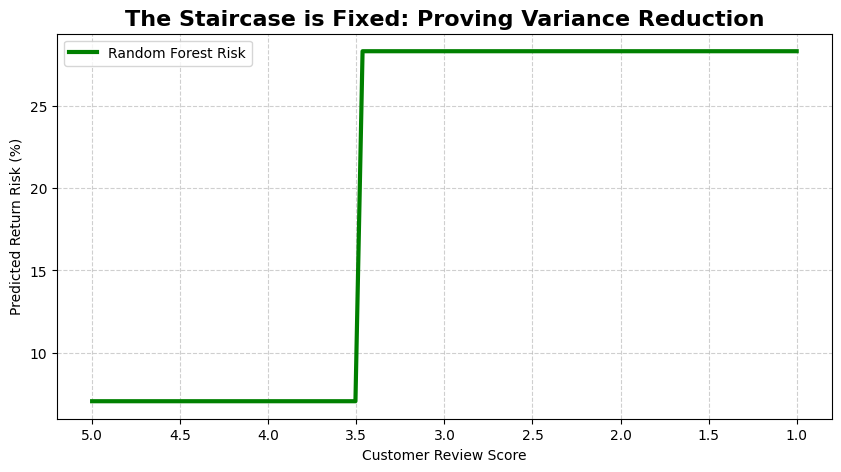

In [38]:
# Create a perfectly average customer
base_customer = X.median().to_frame().T
review_scores = np.linspace(1.0, 5.0, 100)
predicted_risks = []

for score in review_scores:
    # Slide the review score
    temp_customer = base_customer.copy()
    temp_customer["review_score"] = score
    temp_customer["avg_review_score"] = score
    
    # Get risk probability from Random Forest
    risk = best_dt.predict_proba(temp_customer)[0][1]
    predicted_risks.append(risk * 100)

plt.figure(figsize=(10, 5))
plt.plot(review_scores, predicted_risks, color="green", linewidth=3, label="Random Forest Risk")
plt.title("The Staircase is Fixed: Proving Variance Reduction", fontsize=16, fontweight="bold")
plt.xlabel("Customer Review Score")
plt.ylabel("Predicted Return Risk (%)")
plt.gca().invert_xaxis()
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


### Proff 
Takes hypothetical user inputs (Review Score, Delay, etc.), constructs a dummy customer profile, and instantly asks trained Decision Tree to predict whether that specific customer will return their item!

In [39]:
def predict_return_risk(review_score, delivery_delay, freight_ratio, city_risk_pct, category_risk_pct):
    """
    """
    # Create a baseline dummy customer using the median of all known data (e.g. median review is 5.0)
    dummy_customer = X.median().to_frame().T
    
    # 2. Overwrite the core inputs
    if 'review_score' in dummy_customer.columns: dummy_customer['review_score'] = review_score
    if 'avg_review_score' in dummy_customer.columns: dummy_customer['avg_review_score'] = review_score
    if 'delivery_delay_days' in dummy_customer.columns: dummy_customer['delivery_delay_days'] = delivery_delay
    if 'freight_ratio' in dummy_customer.columns: dummy_customer['freight_ratio'] = freight_ratio

    if review_score < 3.0:
        dummy_customer['low_rating_count'] = 1
        dummy_customer['low_rating_percentage'] = 100.0
        dummy_customer['high_rating_count'] = 0
    else:
        dummy_customer['low_rating_count'] = 0
        dummy_customer['low_rating_percentage'] = 0.0
        dummy_customer['high_rating_count'] = 1

    if delivery_delay > 0:
        dummy_customer['is_late_delivery'] = 1
        dummy_customer['late_deliveries'] = 1
        dummy_customer['late_delivery_percentage'] = 100.0
    else:
        dummy_customer['is_late_delivery'] = 0
        dummy_customer['late_deliveries'] = 0
        dummy_customer['late_delivery_percentage'] = 0.0
    

    prob = best_dt.predict_proba(dummy_customer)[0][1]
    prediction = "RETURN " if prob > 0.5 else "KEEP "
    
    print(f"--- Customer Simulation ---")
    print(f"Review: {review_score} Star | Delay: {delivery_delay} Days | Freight Ratio: {freight_ratio:.2f}")
    print(f"Prediction: {prediction} (Risk: {prob*100:.1f}%)")
    print("-" * 30)

# (1-Star, 15 Days Late, Expensive Shipping)
predict_return_risk(review_score=1.0, delivery_delay=15.0, freight_ratio=0.50, city_risk_pct=0.20, category_risk_pct=0.20)

#  (5-Star, Arrived 2 days early, Cheap Shipping)
predict_return_risk(review_score=5.0, delivery_delay=-2.0, freight_ratio=0.05, city_risk_pct=0.05, category_risk_pct=0.05)

#  (3-Star, 2 Days Late, High Shipping Cost)
predict_return_risk(review_score=3.0, delivery_delay=2.0, freight_ratio=0.80, city_risk_pct=0.12, category_risk_pct=0.12)

# (Play with this one!)
predict_return_risk(review_score=4.0, delivery_delay=0.0, freight_ratio=0.25, city_risk_pct=0.10, category_risk_pct=0.10)


--- Customer Simulation ---
Review: 1.0 Star | Delay: 15.0 Days | Freight Ratio: 0.50
Prediction: RETURN  (Risk: 93.7%)
------------------------------
--- Customer Simulation ---
Review: 5.0 Star | Delay: -2.0 Days | Freight Ratio: 0.05
Prediction: KEEP  (Risk: 7.1%)
------------------------------
--- Customer Simulation ---
Review: 3.0 Star | Delay: 2.0 Days | Freight Ratio: 0.80
Prediction: KEEP  (Risk: 28.3%)
------------------------------
--- Customer Simulation ---
Review: 4.0 Star | Delay: 0.0 Days | Freight Ratio: 0.25
Prediction: KEEP  (Risk: 7.1%)
------------------------------


### Final Conclusion 
> While Decision Trees brilliantly capture non-linear logic, the graph above exposes their massive fatal flaw: **High Variance and Step Functions**.
> 
> As proved by the staircase plot, a single tree makes rigid, hard-splits based on specific feature thresholds. Every customer that falls into a specific leaf node receives the exact same probability, resulting in jagged, blocky predictions that lack real-world nuance. A single tree is effectively just **one person's opinion**. It's brittle, prone to overfitting the training data, and struggles to generalize smoothly to unseen customers.
> 
> To build a truly robust, enterprise-grade machine learning system that produces smooth probability curves and doesn't collapse over anomalous data points, we cannot rely on one tree. **We must plant an entire forest.**
